# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [26]:
!git clone https://github.com/AustinChinn03/assignments.git

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score


fatal: destination path 'assignments' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Linear models can produce any value without constraint, whereas general linear models, logistic models, etc. can be constrained to real-world values or probabilities that are interpretable.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary and categorical cross entropy are effective at heavily punishing confident incorrect predictions by using logarithmic relationships to evaluate loss in testing.

3. True or false, and explain: Logistic regression is a linear model.

True, logistic regression is structured as a coefficient and function which is the definition of a linear model.

4. True or false, and explain: Logistic regression cannot be used for classification.

False, logistic regression is effective for classification as its output can be contstrained to values 0 - 1, indicating probability.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No, that is the case for linear regression, but change in the coefficient of logistic regression affects the log-odds.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False, logistic models are still linear in their parameters, so feature engineering remains important to the shaping of the model output

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False, OLS is very useful for relationships that are used to predict continuous outcomes across a range of values that does not require strict constraint.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [5]:
# Q2.1

# Load data
drop = pd.read_csv("./assignments/data/data.csv", delimiter=";")

cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

drop = drop[cols]

# Drop missing values
drop = drop.dropna()

# Create binary dropout dummy variable
drop["Dropout"] = (drop["Target"] == "Dropout").astype(int)
drop.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [8]:
# Q2.2

# Set model variables
X = drop[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]
y = drop["Dropout"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coefs = pd.Series(model.coef_[0], index=X.columns)
print(coefs)


Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


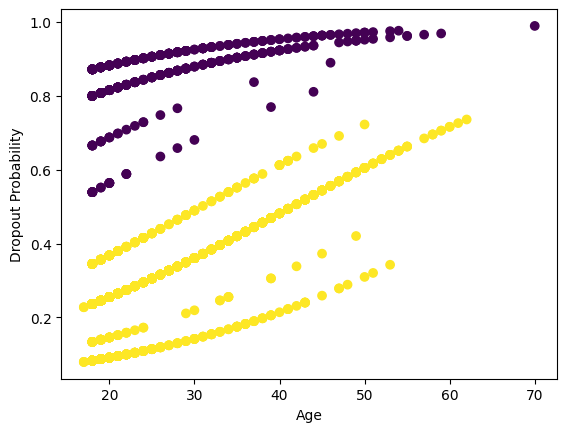

-0.6125849339840048


In [19]:
# Q2.3

# Create probabilities of dropout and not dropout
probs = model.predict_proba(X)[:, 1]

# Add probabilities to dataframe
drop["prob"] = probs

# Plot relationship
plt.scatter(drop["Age at enrollment"], drop["prob"],
            c = drop["Tuition fees up to date"])
plt.xlabel("Age")
plt.ylabel("Dropout Probability")
plt.show()

tuit_means = drop.groupby("Tuition fees up to date")["prob"].mean()

tuit_effect = tuit_means[1] - tuit_means[0]
print(tuit_effect)

# Being up to date on tuition payments decreases the chance of dropping out by
# 61% on average. This effect seems to be most prounouced at younger ages.

In [25]:
# Q2.4

# Generate predictions
preds = model.predict(X)

# Generate confusion matrix and accuracy score
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)

print(cm)
print("\nAccuracy:", acc)

[[2841  162]
 [ 891  530]]

Accuracy: 0.7619801084990958


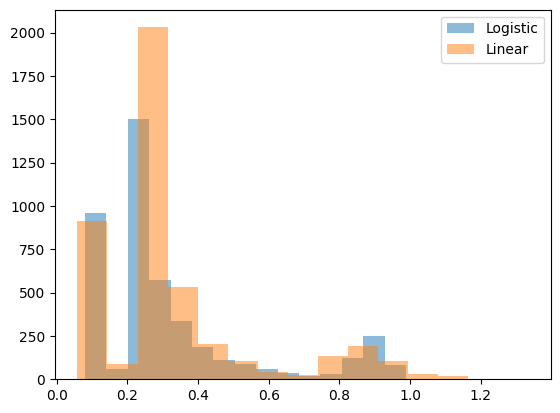


Linear model accuracy: 0.7633363471971067


In [31]:
# Q2.5

# Fit linear regression model on same variables
lin = LinearRegression()
lin.fit(X, y)

# Create linear predictions
lin_probs = lin.predict(X)

plt.hist(probs, alpha=0.5, label="Logistic", bins = 15)
plt.hist(lin_probs, alpha=0.5, label="Linear", bins = 15)
plt.legend()
plt.show()

lin_preds = (lin_probs >= 0.5).astype(int)

lin_acc = accuracy_score(y, lin_preds)
print("\nLinear model accuracy:", lin_acc)

# Linear model has slightly higher accuracy than the logistic model

In [ ]:
# Q2.6

# Students at highest risk of dropping out are those who are older, not on
# scholarship, not up to date on tuition payments, and have student debt.
# Schools can improve student outcomes by providing financial services and
# advising for students, and programs to help better engage older students.

In [36]:
# Q2.7

# Establish variables
X = drop[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y = drop["Target"]

# Fit polynomial logistic regression
multi = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi.fit(X, y)

preds = multi.predict(X)
probs = multi.predict_proba(X)

cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)

print(cm)
print("\nAccuracy:", acc)
print(probs)

# No values in the second class are predicted, creating a reduction in accuracy
# over previous models, the probabilities don't appear to predict the second
# class either

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

Accuracy: 0.7045660036166366
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 ...
 [0.07193813 0.14064437 0.78741751]
 [0.18422683 0.21266883 0.60310434]
 [0.11780804 0.1769832  0.70520876]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [ ]:
# Q3.1

# Load data
liver = pd.read_csv("cirrhosis.csv")
liver = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

liver = liver.dropna()

df["Survival"] = df["Status"].isin(["C", "CL"]).astype(int)

df = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)


In [ ]:
# Q3.2

In [ ]:
# Q3.3

In [ ]:
# Q3.4

In [ ]:
# Q3.5

In [ ]:
# Q3.6

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?